In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style général
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("husl")

print("✅ Librairies chargées !")

✅ Librairies chargées !


In [11]:
df = pd.read_csv(".\\data\\mart_demographie.csv")

print(f"✅ {len(df)} lignes chargées")
print(f"Colonnes : {list(df.columns)}")
print(df.head())

✅ 862 lignes chargées
Colonnes : ['YEAR_PATH_STARTED', 'REGION', 'AGE_GROUP', 'GENDER', 'NB_ETUDIANTS', 'NB_ETUDIANTS_UNIQUES', 'TAUX_CHOMAGE_T3_2025', 'TAUX_CHOMAGE_T3_2024']
   YEAR_PATH_STARTED                REGION  AGE_GROUP         GENDER  \
0               2022  Auvergne-Rhône-Alpes  20-24 ans              M   
1               2022  Auvergne-Rhône-Alpes  25-29 ans              F   
2               2022  Auvergne-Rhône-Alpes  25-29 ans              M   
3               2022  Auvergne-Rhône-Alpes  25-29 ans  Non renseigné   
4               2022  Auvergne-Rhône-Alpes  30-34 ans              F   

   NB_ETUDIANTS  NB_ETUDIANTS_UNIQUES  TAUX_CHOMAGE_T3_2025  \
0             1                     1                   6.6   
1             4                     4                   6.6   
2             8                     8                   6.6   
3            11                    11                   6.6   
4             9                     9                   6.6   

   TAUX_CHOM

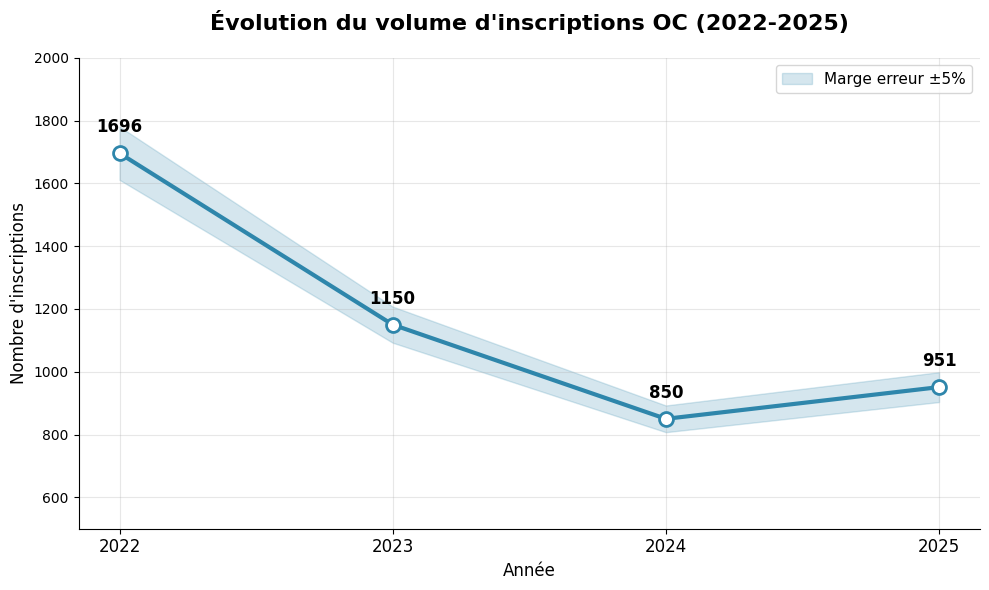

✅ Graphique sauvegardé !


In [12]:
# ANALYSE 1 — Volume d'inscriptions par année (courbe + zone erreur)
a1 = df.groupby('YEAR_PATH_STARTED')['NB_ETUDIANTS'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

x = a1['YEAR_PATH_STARTED'].astype(str)
y = a1['NB_ETUDIANTS']
erreur = y * 0.05  # 5% d'erreur

# Zone d'erreur
ax.fill_between(range(len(x)), y - erreur, y + erreur, 
                alpha=0.2, color=BLEU, label='Marge erreur ±5%')

# Courbe principale
ax.plot(range(len(x)), y, color=BLEU, linewidth=3, marker='o', 
        markersize=10, markerfacecolor='white', markeredgewidth=2)

# Valeurs sur les points
for i, (val, xi) in enumerate(zip(y, x)):
    ax.annotate(f'{val}', (i, val), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=12, fontweight='bold')

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, fontsize=12)
ax.set_title("Évolution du volume d'inscriptions OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Nombre d'inscriptions", fontsize=12)
ax.set_ylim(500, 2000)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse1_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé !")

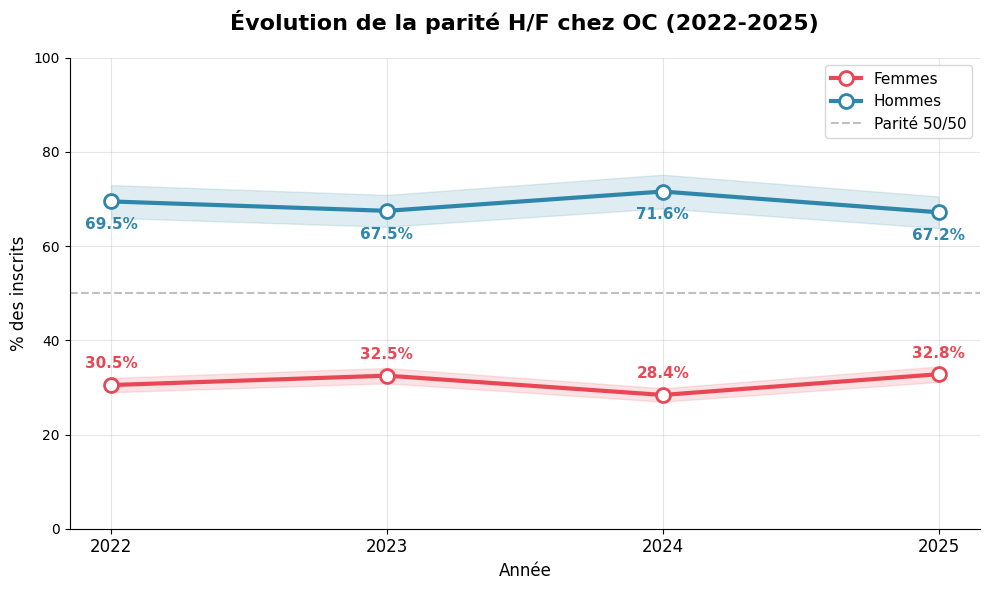

✅ Graphique 2 sauvegardé !


In [13]:
# ANALYSE 2 — Parité H/F globale par année
a2 = df[df['GENDER'].isin(['F', 'M'])].groupby(['YEAR_PATH_STARTED', 'GENDER'])['NB_ETUDIANTS'].sum().reset_index()
a2_pivot = a2.pivot(index='YEAR_PATH_STARTED', columns='GENDER', values='NB_ETUDIANTS')
a2_pct = a2_pivot.div(a2_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))

x = a2_pct.index.astype(str)
y_f = a2_pct['F']
y_m = a2_pct['M']

ax.fill_between(range(len(x)), y_f - y_f*0.05, y_f + y_f*0.05, alpha=0.15, color=ROSE)
ax.fill_between(range(len(x)), y_m - y_m*0.05, y_m + y_m*0.05, alpha=0.15, color=BLEU)

ax.plot(range(len(x)), y_f, color=ROSE, linewidth=3, marker='o',
        markersize=10, markerfacecolor='white', markeredgewidth=2, label='Femmes')
ax.plot(range(len(x)), y_m, color=BLEU, linewidth=3, marker='o',
        markersize=10, markerfacecolor='white', markeredgewidth=2, label='Hommes')

for i, (vf, vm) in enumerate(zip(y_f, y_m)):
    ax.annotate(f'{vf:.1f}%', (i, vf), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=11, color=ROSE, fontweight='bold')
    ax.annotate(f'{vm:.1f}%', (i, vm), textcoords="offset points",
                xytext=(0, -20), ha='center', fontsize=11, color=BLEU, fontweight='bold')

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, fontsize=12)
ax.set_title("Évolution de la parité H/F chez OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("% des inscrits", fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Parité 50/50')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse2_parite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 2 sauvegardé !")

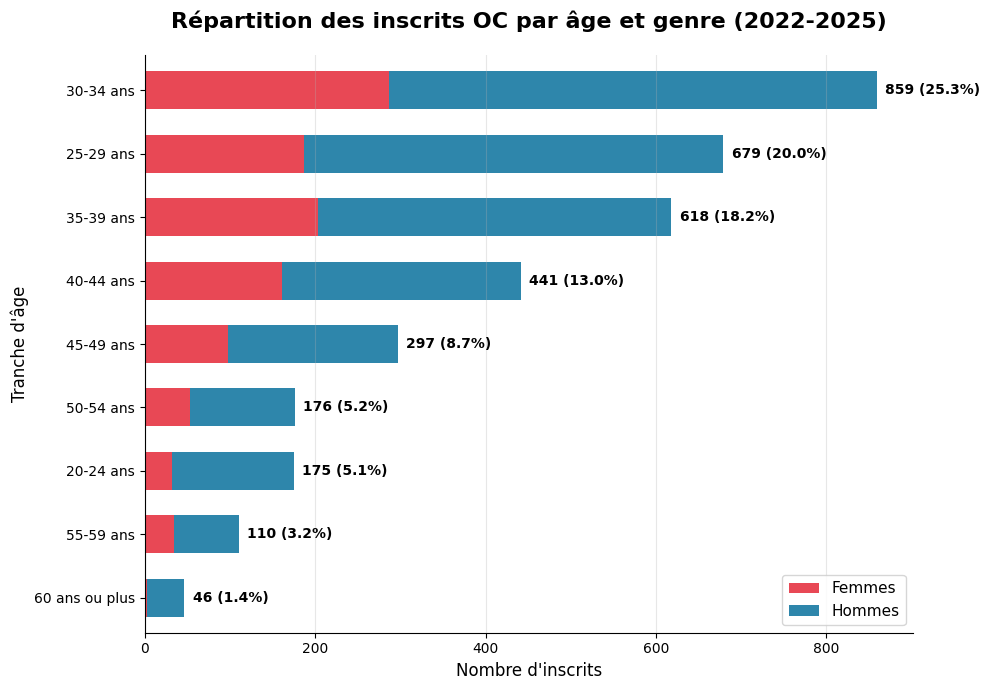

✅ Graphique 3 sauvegardé !


In [14]:
# ANALYSE 3 — Profil d'âge avec répartition H/F
a3 = df[df['GENDER'].isin(['F', 'M'])].groupby(['AGE_GROUP', 'GENDER'])['NB_ETUDIANTS'].sum().reset_index()
a3_pivot = a3.pivot(index='AGE_GROUP', columns='GENDER', values='NB_ETUDIANTS').fillna(0)

# Ordre par total décroissant
a3_pivot['TOTAL'] = a3_pivot.sum(axis=1)
a3_pivot = a3_pivot.sort_values('TOTAL', ascending=True)
a3_pivot = a3_pivot.drop('TOTAL', axis=1)

fig, ax = plt.subplots(figsize=(10, 7))

a3_pivot.plot(kind='barh', stacked=True, ax=ax,
              color={'F': ROSE, 'M': BLEU}, width=0.6)

# Totaux sur les barres
totaux = a3_pivot.sum(axis=1)
for i, (idx, total) in enumerate(totaux.items()):
    pct = round(total / totaux.sum() * 100, 1)
    ax.text(total + 10, i, f'{int(total)} ({pct}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_title("Répartition des inscrits OC par âge et genre (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Nombre d'inscrits", fontsize=12)
ax.set_ylabel("Tranche d'âge", fontsize=12)
ax.legend(['Femmes', 'Hommes'], fontsize=11)
ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse3_age_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 3 sauvegardé !")

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Téléchargement automatique du GeoJSON des régions françaises
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
france = gpd.read_file(url)

print(f"✅ Carte chargée - {len(france)} régions")
print(france['nom'].tolist())

✅ Carte chargée - 13 régions
['Île-de-France', 'Centre-Val de Loire', 'Bourgogne-Franche-Comté', 'Normandie', 'Hauts-de-France', 'Grand Est', 'Pays de la Loire', 'Bretagne', 'Nouvelle-Aquitaine', 'Occitanie', 'Auvergne-Rhône-Alpes', "Provence-Alpes-Côte d'Azur", 'Corse']


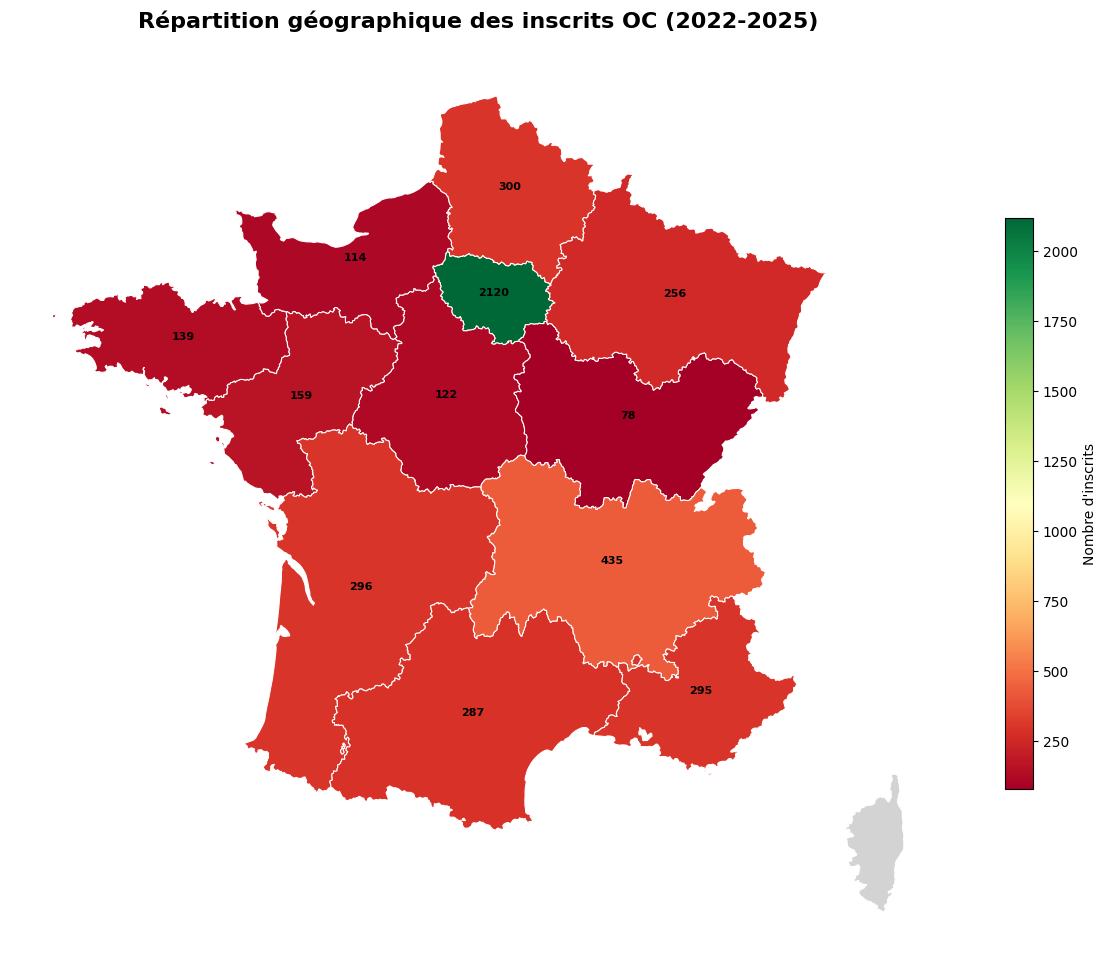

✅ Carte sauvegardée !


In [16]:
# ANALYSE 4 — Carte de France des inscrits OC
a4 = df.groupby('REGION')['NB_ETUDIANTS'].sum().reset_index()
a4.columns = ['nom', 'NB_ETUDIANTS']

# Harmonisation des noms
a4['nom'] = a4['nom'].replace({
    'Centre-Val-de-Loire': 'Centre-Val de Loire',
    'DROM': None
})
a4 = a4.dropna(subset=['nom'])

# Fusion avec la carte
france_data = france.merge(a4, on='nom', how='left')

fig, ax = plt.subplots(figsize=(12, 10))

france_data.plot(
    column='NB_ETUDIANTS',
    cmap='RdYlGn',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': "Nombre d'inscrits", 'shrink': 0.6},
    ax=ax,
    missing_kwds={'color': 'lightgrey'}
)

# Annotations
for idx, row in france_data.iterrows():
    if row['NB_ETUDIANTS'] > 0:
        centroid = row.geometry.centroid
        ax.annotate(f"{int(row['NB_ETUDIANTS'])}",
                   xy=(centroid.x, centroid.y),
                   ha='center', fontsize=8, fontweight='bold', color='black')

ax.set_title("Répartition géographique des inscrits OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('analyse4_carte.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Carte sauvegardée !")


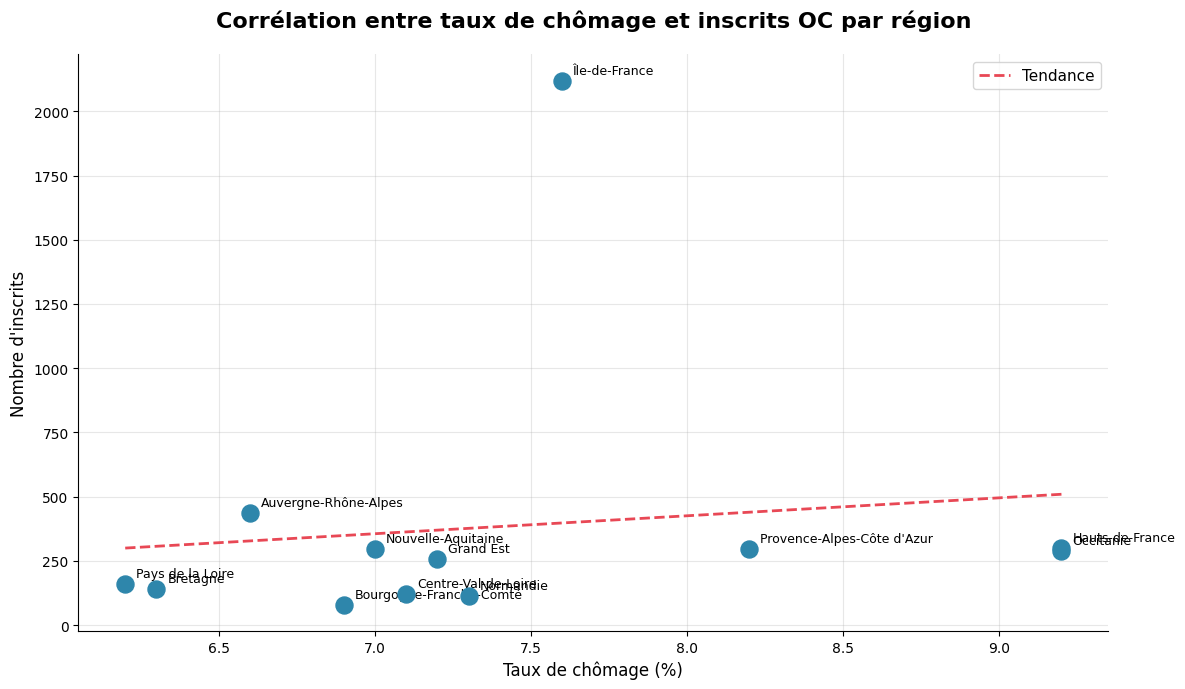

✅ Graphique 5 sauvegardé !


In [17]:
# ANALYSE 5 — Corrélation chômage vs inscrits
BLEU = '#2E86AB'
ROSE = '#E84855'
VERT = '#3BB273'
ORANGE = '#F18F01'

a5 = df[df['REGION'] != 'DROM'].groupby('REGION').agg(
    TOTAL_ETUDIANTS=('NB_ETUDIANTS', 'sum'),
    TAUX_CHOMAGE=('TAUX_CHOMAGE_T3_2025', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(a5['TAUX_CHOMAGE'], a5['TOTAL_ETUDIANTS'], 
           color=BLEU, s=150, zorder=5)

for _, row in a5.iterrows():
    ax.annotate(row['REGION'],
                (row['TAUX_CHOMAGE'], row['TOTAL_ETUDIANTS']),
                textcoords="offset points",
                xytext=(8, 5), fontsize=9)

import numpy as np
z = np.polyfit(a5['TAUX_CHOMAGE'], a5['TOTAL_ETUDIANTS'], 1)
p = np.poly1d(z)
x_line = np.linspace(a5['TAUX_CHOMAGE'].min(), a5['TAUX_CHOMAGE'].max(), 100)
ax.plot(x_line, p(x_line), color=ROSE, linewidth=2, 
        linestyle='--', label='Tendance')

ax.set_title("Corrélation entre taux de chômage et inscrits OC par région",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Taux de chômage (%)", fontsize=12)
ax.set_ylabel("Nombre d'inscrits", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse5_chomage.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 5 sauvegardé !")
        

In [18]:
from scipy import stats

# Calcul de la corrélation de Pearson
corr, p_value = stats.pearsonr(a5['TAUX_CHOMAGE'], a5['TOTAL_ETUDIANTS'])

print(f"Coefficient de corrélation : {corr:.3f}")
print(f"P-value : {p_value:.3f}")

if abs(corr) < 0.3:
    interpretation = "❌ Pas de corrélation significative"
elif abs(corr) < 0.6:
    interpretation = "⚠️ Corrélation modérée"
else:
    interpretation = "✅ Corrélation forte"

print(f"Interprétation : {interpretation}")

# Afficher sur le graphique
ax.text(0.05, 0.95, f'r = {corr:.2f} — {interpretation}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

Coefficient de corrélation : 0.125
P-value : 0.698
Interprétation : ❌ Pas de corrélation significative


Text(0.05, 0.95, 'r = 0.13 — ❌ Pas de corrélation significative')

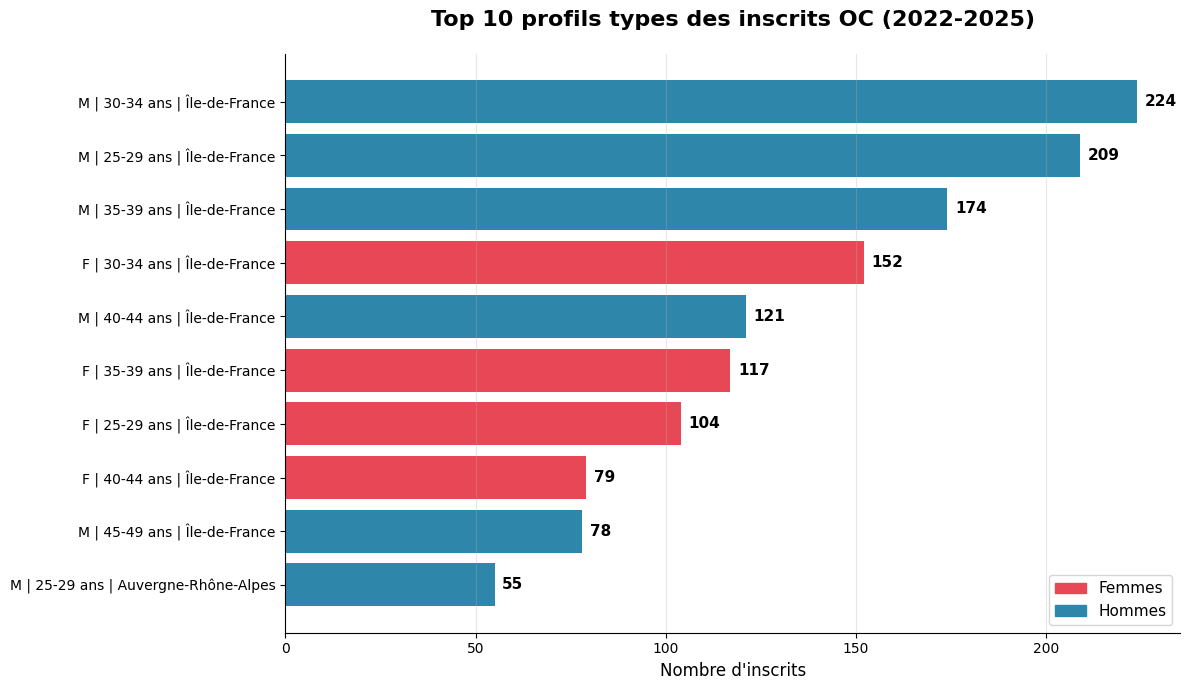

✅ Graphique 6 sauvegardé !


In [20]:
# ANALYSE 6 — Top 10 profils type
BLEU = '#2E86AB'
ROSE = '#E84855'
VERT = '#3BB273'

a6 = df[df['GENDER'].isin(['F', 'M'])].groupby(['GENDER', 'AGE_GROUP', 'REGION'])['NB_ETUDIANTS'].sum().reset_index()
a6 = a6.sort_values('NB_ETUDIANTS', ascending=True).tail(10)
a6['PROFIL'] = a6['GENDER'] + ' | ' + a6['AGE_GROUP'] + ' | ' + a6['REGION']

fig, ax = plt.subplots(figsize=(12, 7))

colors = [ROSE if g == 'F' else BLEU for g in a6['GENDER']]
bars = ax.barh(a6['PROFIL'], a6['NB_ETUDIANTS'], color=colors)

for bar, val in zip(bars, a6['NB_ETUDIANTS']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=11, fontweight='bold')

ax.set_title("Top 10 profils types des inscrits OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Nombre d'inscrits", fontsize=12)
ax.grid(axis='x', alpha=0.3)

import matplotlib.patches as mpatches
rouge_patch = mpatches.Patch(color=ROSE, label='Femmes')
bleu_patch = mpatches.Patch(color=BLEU, label='Hommes')
ax.legend(handles=[rouge_patch, bleu_patch], fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('analyse6_profil_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 6 sauvegardé !")

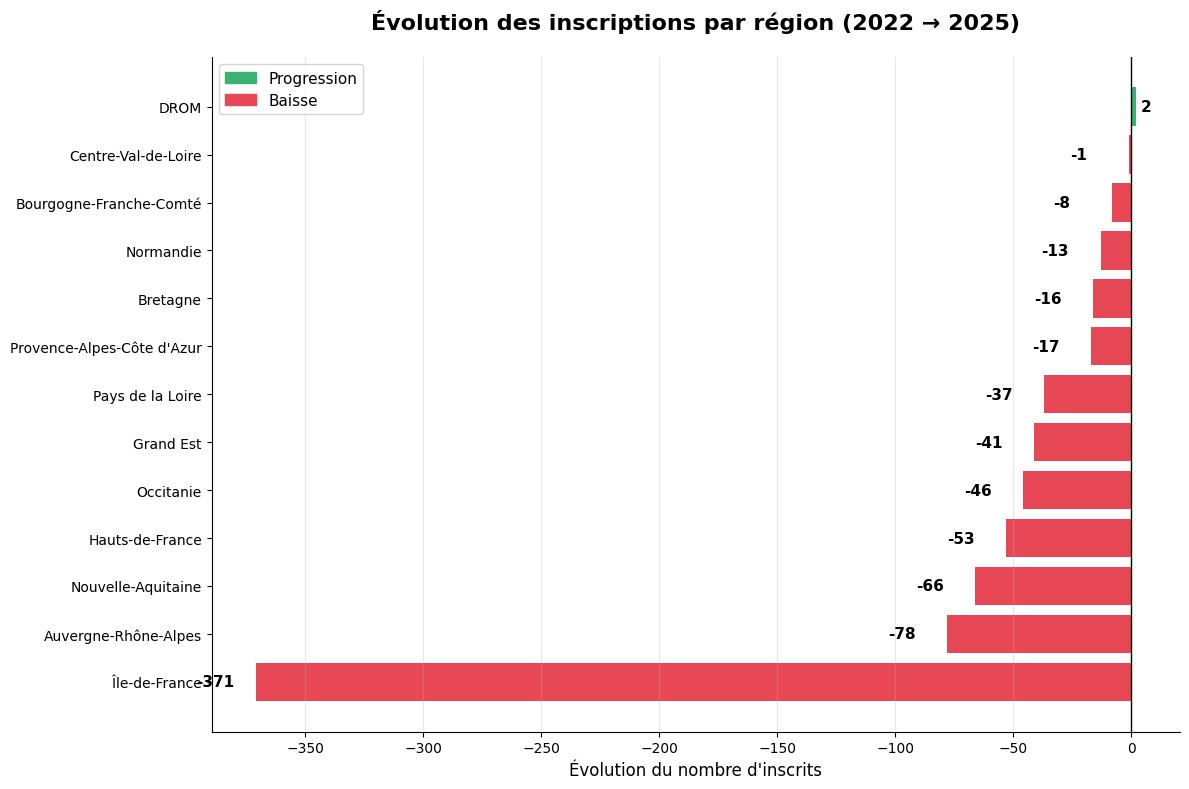

✅ Graphique 7 sauvegardé !


In [24]:
# ANALYSE 7 — Évolution des régions 2022 vs 2025 (DROM inclus)
BLEU = '#2E86AB'
ROSE = '#E84855'
VERT = '#3BB273'

df['YEAR_PATH_STARTED'] = df['YEAR_PATH_STARTED'].astype(str)

a7 = df.groupby(['REGION', 'YEAR_PATH_STARTED'])['NB_ETUDIANTS'].sum().reset_index()

a7_2022 = a7[a7['YEAR_PATH_STARTED'] == '2022'][['REGION', 'NB_ETUDIANTS']].rename(columns={'NB_ETUDIANTS': 'N2022'})
a7_2025 = a7[a7['YEAR_PATH_STARTED'] == '2025'][['REGION', 'NB_ETUDIANTS']].rename(columns={'NB_ETUDIANTS': 'N2025'})

a7_final = a7_2022.merge(a7_2025, on='REGION')
a7_final['EVOLUTION'] = a7_final['N2025'] - a7_final['N2022']
a7_final = a7_final.sort_values('EVOLUTION', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = [VERT if v >= 0 else ROSE for v in a7_final['EVOLUTION']]
bars = ax.barh(a7_final['REGION'], a7_final['EVOLUTION'], color=colors)

for bar, val in zip(bars, a7_final['EVOLUTION']):
    offset = 2 if val >= 0 else -25
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=11, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title("Évolution des inscriptions par région (2022 → 2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Évolution du nombre d'inscrits", fontsize=12)
ax.grid(axis='x', alpha=0.3)

import matplotlib.patches as mpatches
vert_patch = mpatches.Patch(color=VERT, label='Progression')
rose_patch = mpatches.Patch(color=ROSE, label='Baisse')
ax.legend(handles=[vert_patch, rose_patch], fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('analyse7_regions_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 7 sauvegardé !")

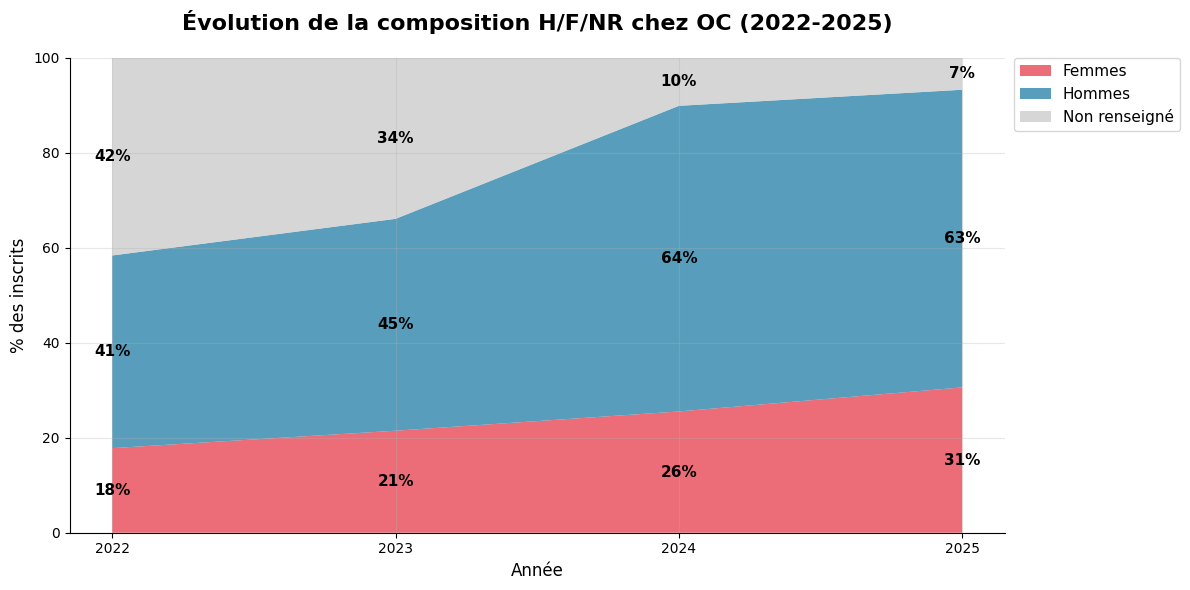

✅ Graphique 8 sauvegardé !


In [31]:
# ANALYSE 8 — Évolution de la composition H/F/NR chez OC
BLEU = '#2E86AB'
ROSE = '#E84855'

df['YEAR_PATH_STARTED'] = df['YEAR_PATH_STARTED'].astype(str)

a8 = df.groupby(['YEAR_PATH_STARTED', 'GENDER'])['NB_ETUDIANTS'].sum().reset_index()
a8_pivot = a8.pivot(index='YEAR_PATH_STARTED', columns='GENDER', values='NB_ETUDIANTS').fillna(0)
a8_pct = a8_pivot.div(a8_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(a8_pct.index.astype(str),
             a8_pct['F'], a8_pct['M'], a8_pct['Non renseigné'],
             labels=['Femmes', 'Hommes', 'Non renseigné'],
             colors=[ROSE, BLEU, '#CCCCCC'],
             alpha=0.8)

# Annotations en noir
for i, year in enumerate(a8_pct.index):
    f = a8_pct.loc[year, 'F']
    m = a8_pct.loc[year, 'M']
    nr = a8_pct.loc[year, 'Non renseigné']

    ax.text(i, f/2, f'{f:.0f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    ax.text(i, f + m/2, f'{m:.0f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    ax.text(i, f + m + nr/2, f'{nr:.0f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='black')

ax.set_title("Évolution de la composition H/F/NR chez OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("% des inscrits", fontsize=12)
ax.set_ylim(0, 100)

# Légende en dehors
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), 
          borderaxespad=0, fontsize=11)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse8_parite_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 8 sauvegardé !")

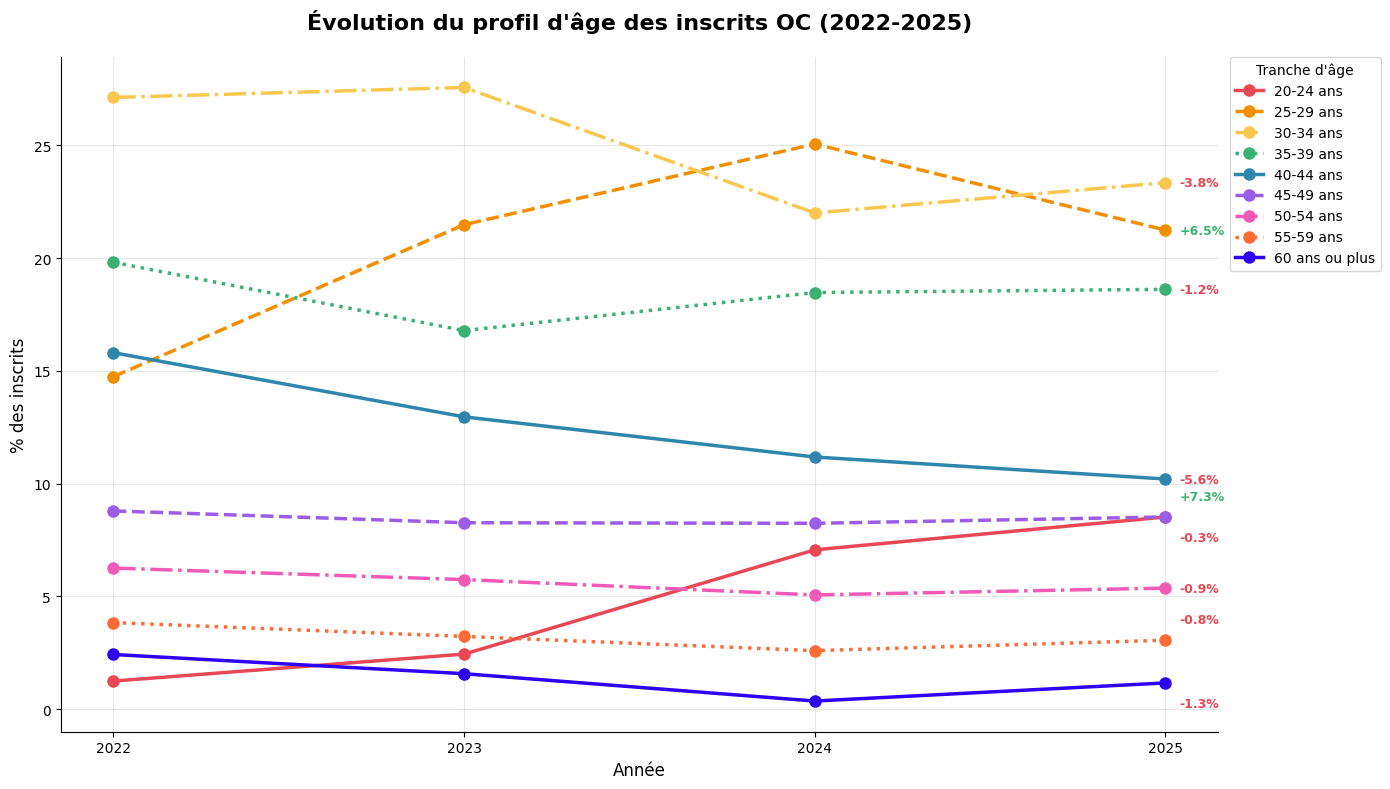

✅ Graphique 9 sauvegardé !


In [42]:
# ANALYSE 9 — Courbes évolution par tranche d'âge avec écart final
COULEURS = [
    '#E84855',  # rouge
    '#F18F01',  # orange
    '#F9C74F',  # jaune
    '#3BB273',  # vert
    '#2E86AB',  # bleu
    '#9B5DE5',  # violet
    '#F15BB5',  # rose vif
    '#FF6B35',  # orange foncé
    '#2D00F7'   # bleu électrique
]

df['YEAR_PATH_STARTED'] = df['YEAR_PATH_STARTED'].astype(str)

a9 = df.groupby(['YEAR_PATH_STARTED', 'AGE_GROUP'])['NB_ETUDIANTS'].sum().reset_index()
a9_pivot = a9.pivot(index='YEAR_PATH_STARTED', columns='AGE_GROUP', values='NB_ETUDIANTS').fillna(0)
a9_pct = a9_pivot.div(a9_pivot.sum(axis=1), axis=0) * 100

linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-']

# Décalages manuels par tranche d'âge
decalages_manuels = {
    '20-24 ans': 15,
    '25-29 ans': 0,
    '30-34 ans': 0,
    '35-39 ans': 0,
    '40-44 ans': 0,
    '45-49 ans': -15,
    '50-54 ans': 0,
    '55-59 ans': 15,
    '60 ans ou plus': -15
}

fig, ax = plt.subplots(figsize=(14, 8))

for i, col in enumerate(a9_pct.columns):
    y = a9_pct[col]
    ax.plot(a9_pct.index, y,
            color=COULEURS[i], linewidth=2.5,
            linestyle=linestyles[i],
            marker='o', markersize=8,
            label=col)
    
    ecart = y.iloc[-1] - y.iloc[0]
    signe = '+' if ecart >= 0 else ''
    couleur_ecart = '#3BB273' if ecart >= 0 else '#E84855'
    decalage = decalages_manuels.get(col, 0)

    ax.annotate(f'{signe}{ecart:.1f}%',
                xy=(a9_pct.index[-1], y.iloc[-1]),
                xytext=(10, decalage),
                textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=couleur_ecart,
                va='center')

ax.set_title("Évolution du profil d'âge des inscrits OC (2022-2025)",
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("% des inscrits", fontsize=12)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1),
          borderaxespad=0, fontsize=10, title="Tranche d'âge")
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('analyse9_age_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 9 sauvegardé !")

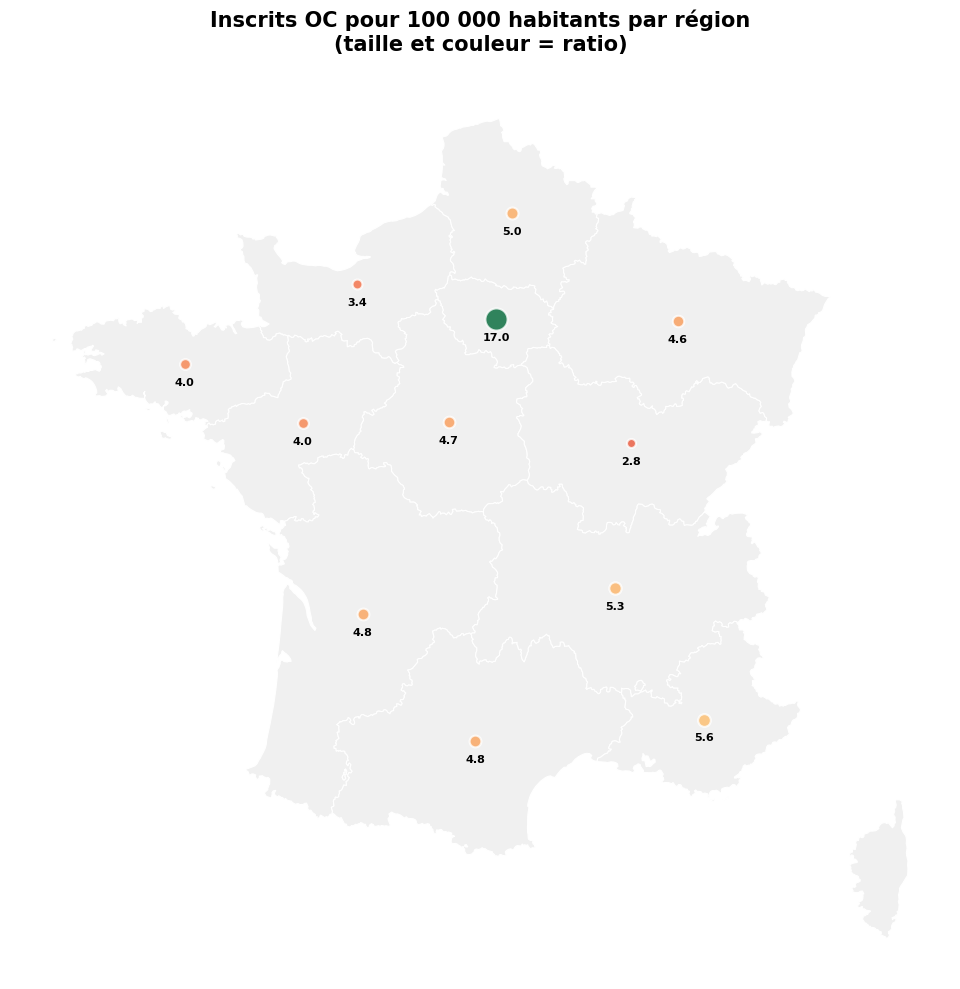

✅ Graphique 10 sauvegardé !


In [45]:
# ANALYSE 10 — Carte de France avec bubbles ratio inscrits / 100 000 habitants
import geopandas as gpd
import matplotlib.pyplot as plt

data_ratio = {
    'nom': ['Île-de-France', "Provence-Alpes-Côte d'Azur", 'Auvergne-Rhône-Alpes',
            'Occitanie', 'Hauts-de-France', 'Grand Est', 'Nouvelle-Aquitaine',
            'Bretagne', 'Pays de la Loire', 'Normandie',
            'Centre-Val de Loire', 'Bourgogne-Franche-Comté'],
    'TOTAL_ETUDIANTS': [2120, 295, 435, 287, 300, 256, 296, 139, 159, 114, 122, 78],
    'POPULATION': [12450849, 5241587, 8260096, 6041232, 5973933, 5544051,
                   6191209, 3475895, 3982000, 3341312, 2581479, 2793080],
}

df_ratio = pd.DataFrame(data_ratio)
df_ratio['INSCRITS_100K'] = (df_ratio['TOTAL_ETUDIANTS'] / df_ratio['POPULATION'] * 100000).round(1)

# Fusion avec carte
url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions-version-simplifiee.geojson"
france = gpd.read_file(url)
france_data = france.merge(df_ratio, on='nom', how='left')

fig, ax = plt.subplots(figsize=(12, 10))

# Fond carte gris neutre
france.plot(color='#f0f0f0', edgecolor='white', linewidth=0.8, ax=ax)

# Bubbles sur les centroïdes
for idx, row in france_data.iterrows():
    if pd.notna(row['INSCRITS_100K']):
        centroid = row.geometry.centroid
        size = row['INSCRITS_100K'] * 15
        color = plt.cm.RdYlGn(row['INSCRITS_100K'] / df_ratio['INSCRITS_100K'].max())
        
        ax.scatter(centroid.x, centroid.y,
                   s=size, color=color,
                   alpha=0.8, edgecolors='white', linewidth=1.5, zorder=5)
        
        ax.annotate(f"{row['INSCRITS_100K']}",
                    xy=(centroid.x, centroid.y),
                    xytext=(0, -15),
                    textcoords='offset points',
                    ha='center', fontsize=8, fontweight='bold', zorder=6)

ax.set_title("Inscrits OC pour 100 000 habitants par région\n(taille et couleur = ratio)",
             fontsize=15, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
plt.savefig('analyse10_carte_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique 10 sauvegardé !")
